Esta es la traducción al español de la continuación del capítulo sobre el entrenamiento de redes neuronales profundas. Este fragmento es crucial porque explica técnicamente **por qué** las redes profundas eran tan difíciles de entrenar antes de 2010.

---



## Los problemas de desvanecimiento y explosión de gradientes

Como se discutió en el Capítulo 9, la segunda fase del algoritmo de **retropropagación (backpropagation)** consiste en ir desde la capa de salida hacia la capa de entrada, propagando el gradiente del error a lo largo del camino. Una vez que el algoritmo ha calculado el gradiente de la función de costo con respecto a cada parámetro de la red, utiliza estos gradientes para actualizar cada parámetro con un paso de **gradiente descendente**.



Lamentablemente, los gradientes suelen hacerse cada vez más pequeños a medida que el algoritmo avanza hacia las capas inferiores. Como resultado, la actualización del gradiente descendente deja los pesos de conexión de las capas inferiores prácticamente sin cambios, y el entrenamiento nunca converge hacia una buena solución. Esto se conoce como el **problema de desvanecimiento de gradientes (vanishing gradients)**. 



En algunos casos puede ocurrir lo contrario: los gradientes pueden crecer cada vez más hasta que las capas reciben actualizaciones de pesos increíblemente grandes y el algoritmo diverge. Este es el **problema de explosión de gradientes (exploding gradients)**, que aparece con mayor frecuencia en las redes neuronales recurrentes (ver Capítulo 13). De manera más general, las redes neuronales profundas sufren de gradientes inestables; diferentes capas pueden aprender a velocidades muy distintas.





Este comportamiento desafortunado fue observado empíricamente hace mucho tiempo, y fue una de las razones por las que las redes neuronales profundas fueron mayormente abandonadas a principios de la década de 2000. No estaba claro qué causaba que los gradientes fueran tan inestables al entrenar una DNN, pero un artículo de 2010 de **Xavier Glorot y Yoshua Bengio** arrojó algo de luz sobre el asunto. 



Los autores encontraron algunos sospechosos, incluyendo la combinación de la popular función de activación **sigmoide (logística)** y la técnica de inicialización de pesos más común en aquel momento (es decir, una distribución normal con una media de 0 y una desviación estándar de 1).





En resumen, demostraron que con esta función de activación y este esquema de inicialización, la varianza de las salidas de cada capa es mucho mayor que la varianza de sus entradas. Al avanzar en la red, la varianza sigue aumentando después de cada capa hasta que la función de activación se **satura** en las capas superiores. Esta saturación empeora por el hecho de que la función sigmoide tiene una media de 0.5, no de 0 (la función tangente hiperbólica tiene una media de 0 y se comporta ligeramente mejor que la sigmoide en redes profundas). 

Al observar la función de activación sigmoide, se puede ver que cuando las entradas se vuelven grandes (negativas o positivas), la función se satura en 0 o 1, con una **derivada extremadamente cercana a 0** (es decir, la curva es plana en ambos extremos). Por lo tanto, cuando comienza la retropropagación, prácticamente no tiene gradiente para propagar de vuelta por la red, y el poco gradiente que existe se sigue diluyendo a medida que la retropropagación avanza por las capas superiores, de modo que realmente no queda nada para las capas inferiores.



### Conceptos clave para tus estudiantes:
* **Saturación:** Es cuando la neurona llega a sus límites (0 o 1) y "deja de responder" a cambios en la entrada. En administración, sería como un mercado saturado donde por más publicidad que hagas, las ventas ya no suben.
* **Derivada cercana a 0:** Si la derivada es cero, el aprendizaje se detiene. Es como intentar bajar una montaña (gradiente descendente) pero llegar a una llanura infinita donde no sabes hacia dónde está el suelo.

<img src = ''>

Para replicar la imagen que adjuntaste (basada en el libro de Géron), necesitamos graficar la función sigmoide junto con su aproximación lineal en el punto central ($z=0$) y las anotaciones correspondientes.

Aquí tienes el código en Python utilizando **Matplotlib** para el dibujo y **Seaborn** para mejorar la estética visual:


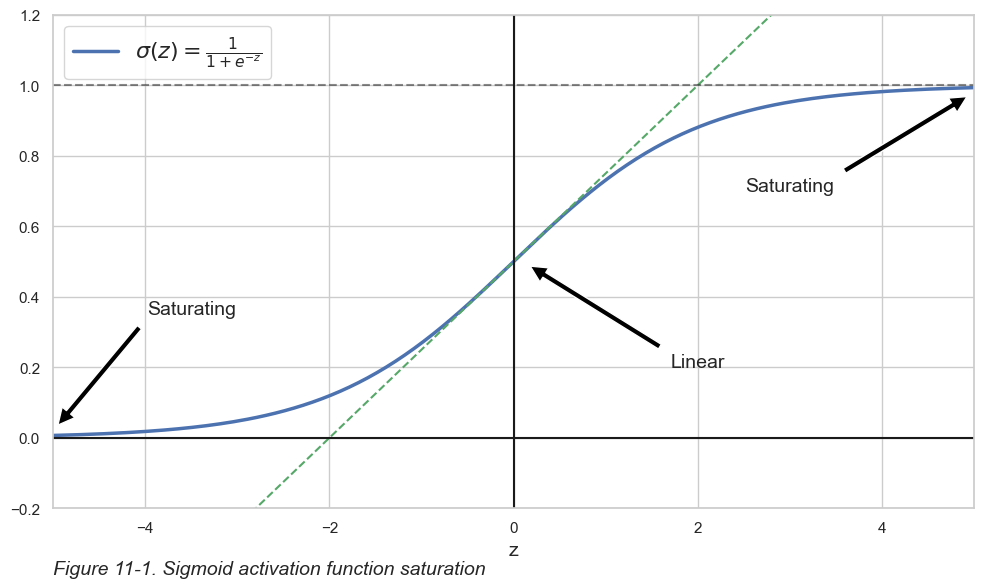

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="whitegrid")

# 1. Definición de la función Sigmoide
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 2. Generación de datos
z = np.linspace(-5, 5, 200)
sigma_z = sigmoid(z)

# Aproximación lineal en z=0 (recta tangente)
# La derivada de sigmoid en z=0 es 0.25, y pasa por (0, 0.5)
# Ecuación: y = 0.25z + 0.5
linear_z = 0.25 * z + 0.5

# 3. Creación del gráfico
plt.figure(figsize=(10, 6))

# Dibujar la función sigmoide (azul, gruesa)
plt.plot(z, sigma_z, "b-", linewidth=2.5, label=r"$\sigma(z) = \frac{1}{1 + e^{-z}}$")

# Dibujar la aproximación lineal (verde, punteada)
plt.plot(z, linear_z, "g--", linewidth=1.5)

# Líneas de referencia (ejes y límites)
plt.axhline(y=0, color='k', linestyle='-', linewidth=1.5) # Eje X
plt.axvline(x=0, color='k', linestyle='-', linewidth=1.5) # Eje Y
plt.axhline(y=1.0, color='k', linestyle='--', alpha=0.5)   # Límite superior

# 4. Anotaciones (Flechas y Texto)
# Saturación derecha
plt.annotate('Saturating', xy=(5, 0.98), xytext=(3, 0.7),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=14, horizontalalignment='center')

# Saturación izquierda
plt.annotate('Saturating', xy=(-5, 0.02), xytext=(-3.5, 0.35),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=14, horizontalalignment='center')

# Región Lineal
plt.annotate('Linear', xy=(0.1, 0.5), xytext=(2, 0.2),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=14, horizontalalignment='center')

# 5. Formato final
plt.xlabel("z", fontsize=14)
plt.axis([-5, 5, -0.2, 1.2]) # Ajuste de límites según la imagen
plt.legend(loc="upper left", fontsize=16)
plt.title("Figure 11-1. Sigmoid activation function saturation", loc='left', y=-0.15, fontsize=14, fontstyle='italic')

plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\sigmoid_activation_function.png", dpi=300)
plt.show()


## Explicación técnica para tu clase:
* **La Recta Verde (Lineal):** Representa la derivada en el origen. Es la zona donde la red aprende mejor porque el gradiente es "grande" ($0.25$).
* **Saturación:** Fíjate que en los extremos ($-5$ y $5$), la curva azul se vuelve casi horizontal. En términos de cálculo, la pendiente (derivada) es casi $0$. Como el entrenamiento depende de multiplicar por esta pendiente, si es $0$, el aprendizaje se detiene.
* **Uso de LaTeX:** En la leyenda usamos `r"$\sigma(z) = \dots$"` para que la fórmula se vea elegante y profesional, igual que en los libros de texto.

# Situación en Administración de Empresas   

Para los estudiantes de Administración de Empresas en la sede de Caucasia, el reto es aterrizar el concepto abstracto de **"Gradientes que se desvanecen"** en una problemática de gestión real. En el Bajo Cauca, la estabilidad financiera de las empresas suele depender de múltiples capas de variables (clima, precios de commodities, orden público, logística).

Aquí tienes el diseño de un proyecto pedagógico que conecta la teoría de Géron con la administración regional.

---

# Proyecto: "El Consultor de Riesgo Profundo: Predicción de Impago en Créditos Agroindustriales"

## 1. El Problema de Negocio
Las cooperativas de crédito en Caucasia enfrentan un problema: los modelos de evaluación simples (regresión lineal) no captan el riesgo real de los agricultores de cacao o arroz, ya que el éxito de estos depende de una cadena de factores interconectados. 

**El desafío:** Construir una Red Neuronal Profunda (DNN) para predecir si un crédito entrará en mora. Sin embargo, al ser una red "profunda" (muchas capas), los estudiantes verán que las primeras capas (las que analizan el entorno macroeconómico) dejan de aprender debido al **desvanecimiento de gradientes**.

---

## 2. Objetivos de Aprendizaje
* **Identificar** el problema de saturación de la función sigmoide en datos financieros.
* **Experimentar** cómo el desvanecimiento de gradientes hace que la red ignore las "raíces" del problema (capas inferiores).
* **Implementar** soluciones técnicas (como cambiar la función de activación o inicialización) para mejorar la toma de decisiones administrativa.

---

## 3. Fases del Proyecto

### Fase A: Preparación del "Historial Crediticio" (Dataset)
Simularemos datos donde el impago no solo depende del cliente, sino de variables "lejanas" (macro):
1.  **Variables de Capa Profunda (Entorno):** Precio del oro, índice de lluvias en el Bajo Cauca, estado de la vía a Medellín.
2.  **Variables de Capa Intermedia (Negocio):** Tipo de cultivo, tamaño de la hectárea.
3.  **Variables de Capa de Salida (Cliente):** Historial de deudas, edad, ingresos mensuales.



### Fase B: El Error del Administrador (Simulación del Problema)
Los estudiantes diseñarán una red usando la configuración "antigua" que menciona el texto:
* **Activación:** Sigmoide en todas las capas.
* **Inicialización:** Normal aleatoria (Media 0, Desviación 1).
* **Resultado esperado:** El modelo tendrá una pérdida (Loss) que no baja. Al analizar los gradientes, verán que las capas que procesan el "Entorno" (precio del oro, vías) tienen gradientes cercanos a 0. **La red está saturada.**



### Fase C: La Optimización Gerencial (Solución)
Siguiendo las soluciones de Glorot y Bengio, los estudiantes deben:
1.  **Cambiar la Sigmoide por ReLU o Tanh:** Para evitar que la curva se vuelva "plana" (saturación).
2.  **Implementar Inicialización Xavier/He:** Para mantener la varianza de la información constante entre capas.

---

## 4. Dinámica de Reflexión "Sello UdeA"
Pide a tus estudiantes que respondan esto en su informe:
> *"Si nuestra red neuronal sufre de desvanecimiento de gradientes en las capas inferiores, significa que nuestro 'Consultor Digital' está tomando decisiones viendo solo el historial del cliente (capa superior) e ignorando por completo el contexto de Caucasia (capas inferiores). ¿Cómo afecta esto la resiliencia de nuestra cooperativa ante una crisis regional?"*

---



## 5. Ejemplo de Código para la Práctica (Python)
Este script permite a los estudiantes visualizar el "gradiente" en las capas para detectar el problema.


In [3]:
import torch
import torch.nn as nn

# Simulamos 20 variables y 5 capas profundas
X = torch.randn(100, 20)
y = torch.randint(0, 2, (100,)).float()

# Red "Defectuosa" (Sigmoide + Inicialización antigua)
model = nn.Sequential(
    nn.Linear(20, 20), nn.Sigmoid(),
    nn.Linear(20, 20), nn.Sigmoid(),
    nn.Linear(20, 20), nn.Sigmoid(),
    nn.Linear(20, 1)
)

# Simulamos un paso de entrenamiento para ver los gradientes
criterion = nn.BCEWithLogitsLoss()
loss = criterion(model(X).squeeze(), y)
loss.backward()

# Visualización del desvanecimiento para los estudiantes
print("--- Magnitud de los gradientes por capa ---")
for i, layer in enumerate(model):
    if isinstance(layer, nn.Linear):
        # Calculamos el promedio del valor absoluto del gradiente
        grad_mean = layer.weight.grad.abs().mean().item()
        print(f"Capa {i}: Magnitud del Gradiente = {grad_mean:.10f}")


--- Magnitud de los gradientes por capa ---
Capa 0: Magnitud del Gradiente = 0.0000213615
Capa 2: Magnitud del Gradiente = 0.0002051840
Capa 4: Magnitud del Gradiente = 0.0012264915
Capa 6: Magnitud del Gradiente = 0.0472927839


## ¿Qué deben observar?
En las capas cercanas a la salida, el gradiente tendrá un valor razonable. En las **Capa 0 y 2**, el valor será casi cero (ej. `0.000000001`). 
**Conclusión administrativa:** "Nuestra red es ciega al contexto inicial porque la señal del error se evaporó antes de llegar a las primeras capas".